# Heart Disease Analysis 

## Data Preperation and Review 

In [30]:
import pandas as pd
import numpy as nu
import matplotlib as plt

In [31]:
Hrt =pd.read_csv(r"C:\Users\USER\Downloads\Dataset Heart Disease.csv")

In [32]:
print(Hrt.shape)

(1048, 13)


In [33]:
Data_Head = Hrt.head()
print(Data_Head)

   Unnamed: 0  age  sex  chest pain type  resting bps  cholesterol  \
0           0   40    1                2          140        289.0   
1           1   49    0                3          160        180.0   
2           2   37    1                2          130        283.0   
3           3   48    0                4          138        214.0   
4           4   54    1                3          150        195.0   

   fasting blood sugar  resting ecg  max heart rate  exercise angina  oldpeak  \
0                    0            0             172                0      0.0   
1                    0            0             156                0      1.0   
2                    0            1              98                0      0.0   
3                    0            0             108                1      1.5   
4                    0            0             122                0      0.0   

   ST slope  target  
0         1       0  
1         2       1  
2         1       0  
3   

In [34]:
info = Hrt.info()
print(info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048 entries, 0 to 1047
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1048 non-null   int64  
 1   age                  1048 non-null   int64  
 2   sex                  1048 non-null   int64  
 3   chest pain type      1048 non-null   int64  
 4   resting bps          1048 non-null   int64  
 5   cholesterol          1048 non-null   float64
 6   fasting blood sugar  1048 non-null   int64  
 7   resting ecg          1048 non-null   int64  
 8   max heart rate       1048 non-null   int64  
 9   exercise angina      1048 non-null   int64  
 10  oldpeak              1048 non-null   float64
 11  ST slope             1048 non-null   int64  
 12  target               1048 non-null   int64  
dtypes: float64(2), int64(11)
memory usage: 106.6 KB
None


In [35]:
view_data_details = Hrt.describe()
print(view_data_details)

        Unnamed: 0          age          sex  chest pain type  resting bps  \
count  1048.000000  1048.000000  1048.000000      1048.000000  1048.000000   
mean    390.841603    53.325382     0.734733         2.817748   132.613550   
std     307.916633     9.397822     0.441686         1.118649    17.367605   
min       0.000000    28.000000     0.000000         1.000000    92.000000   
25%     130.750000    46.000000     0.000000         2.000000   120.000000   
50%     262.000000    54.000000     1.000000         3.000000   130.000000   
75%     657.250000    60.000000     1.000000         4.000000   140.000000   
max    1189.000000    77.000000     1.000000         4.000000   200.000000   

       cholesterol  fasting blood sugar  resting ecg  max heart rate  \
count  1048.000000          1048.000000  1048.000000     1048.000000   
mean    245.172710             0.162214     0.606870      142.918893   
std      57.101359             0.368823     0.763313       24.427115   
min      

Target= Heart Disease(1)
Sex= Male(1), Female(0)

Remove unnecessary data 

In [36]:
Hrt = Hrt.drop(columns=['Unnamed: 0'])

## Data Relations

### General Level of high chest pain 

In [37]:
High_CP = Hrt[Hrt['chest pain type'] > 3]
High_CP

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
3,48,0,4,138,214.0,0,0,108,1,1.5,2,1
8,37,1,4,140,207.0,0,0,130,1,1.5,2,1
13,49,1,4,140,234.0,0,0,140,1,1.0,2,1
16,38,1,4,110,196.0,0,0,166,0,0.0,2,1
18,60,1,4,100,248.0,0,0,125,0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1017,59,1,4,178,270.0,0,0,145,0,4.2,0,1
1033,69,0,4,140,239.0,0,1,151,0,1.8,2,1
1034,65,1,4,138,282.0,1,0,174,0,1.4,1,0
1037,66,0,4,150,226.0,0,1,114,0,2.6,0,1


### High Cholesterole levels 
High number of people with cholesterole level above the reaserched average of 170

In [38]:
High_Col = Hrt[Hrt['cholesterol'] > 170]
High_Col

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289.0,0,0,172,0,0.0,1,0
1,49,0,3,160,180.0,0,0,156,0,1.0,2,1
2,37,1,2,130,283.0,0,1,98,0,0.0,1,0
3,48,0,4,138,214.0,0,0,108,1,1.5,2,1
4,54,1,3,150,195.0,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1042,64,1,3,140,335.0,0,1,158,0,0.0,2,0
1043,68,0,3,120,211.0,0,0,115,0,1.5,1,1
1045,52,1,1,128,255.0,0,1,161,1,0.0,2,0
1046,59,1,4,160,273.0,0,0,125,0,0.0,2,0


### Age
Old age with high heart rate 

In [39]:
Age_Old = Hrt[(Hrt['max heart rate'] > 142) & (Hrt['age'] > 50) ]
Age_Old

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
15,54,0,2,120,273.0,0,0,150,0,1.5,2,0
29,51,1,2,125,188.0,0,0,145,0,0.0,1,0
43,52,1,3,140,259.0,0,1,170,0,0.0,1,0
55,51,0,2,160,194.0,0,0,170,0,0.0,1,0
70,57,1,2,140,265.0,0,1,145,1,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1034,65,1,4,138,282.0,1,0,174,0,1.4,1,0
1038,55,0,2,135,250.0,0,0,161,0,1.4,1,1
1041,52,1,1,108,233.0,1,1,147,0,0.1,2,1
1042,64,1,3,140,335.0,0,1,158,0,0.0,2,0


Less than 50 with high heart rate.

In [40]:
Age_Young = Hrt[(Hrt['max heart rate'] > 142) & (Hrt['age'] < 50) ]
Age_Young

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289.0,0,0,172,0,0.0,1,0
1,49,0,3,160,180.0,0,0,156,0,1.0,2,1
5,39,1,3,120,339.0,0,0,170,0,0.0,1,0
6,45,0,2,130,237.0,0,0,170,0,0.0,1,0
12,39,1,2,120,204.0,0,0,145,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1014,44,1,1,112,290.0,0,0,153,0,0.0,2,0
1021,44,1,3,140,235.0,0,0,180,0,0.0,2,1
1026,46,1,2,101,197.0,1,1,156,0,0.0,2,1
1032,43,1,1,115,303.0,0,1,181,0,1.2,1,1


### Gender
#### High Chest Pain in Males(1)

In [41]:
Male = Hrt[(Hrt['sex'] == 1 ) & (Hrt['chest pain type'] >= 3 ) ]
Male

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
4,54,1,3,150,195.0,0,0,122,0,0.0,1,0
5,39,1,3,120,339.0,0,0,170,0,0.0,1,0
8,37,1,4,140,207.0,0,0,130,1,1.5,2,1
13,49,1,4,140,234.0,0,0,140,1,1.0,2,1
16,38,1,4,110,196.0,0,0,166,0,0.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1021,44,1,3,140,235.0,0,0,180,0,0.0,2,1
1022,68,1,3,118,277.0,0,1,151,0,1.0,2,1
1034,65,1,4,138,282.0,1,0,174,0,1.4,1,0
1042,64,1,3,140,335.0,0,1,158,0,0.0,2,0


#### High Chest pain in Females(0) 

In [42]:
Female = Hrt[(Hrt['sex'] == 0 ) & (Hrt['chest pain type'] >= 3 ) ]
Female

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
1,49,0,3,160,180.0,0,0,156,0,1.0,2,1
3,48,0,4,138,214.0,0,0,108,1,1.5,2,1
10,37,0,3,130,211.0,0,0,142,0,0.0,1,0
14,42,0,3,115,211.0,0,1,137,0,0.0,1,0
39,48,0,4,150,227.0,0,0,130,1,1.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1033,69,0,4,140,239.0,0,1,151,0,1.8,2,1
1037,66,0,4,150,226.0,0,1,114,0,2.6,0,1
1040,60,0,3,120,178.0,1,1,96,0,0.0,2,1
1043,68,0,3,120,211.0,0,0,115,0,1.5,1,1


### ECG
Resting ECG(1) = heart attack 

#### Male

In [43]:
ECG_Male = Hrt[(Hrt['resting ecg'] == 1 ) & (Hrt['sex'] == 1 ) ]
ECG_Male

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
2,37,1,2,130,283.0,0,1,98,0,0.0,1,0
11,58,1,2,136,164.0,0,1,99,1,2.0,2,1
26,53,1,4,124,260.0,0,1,112,1,3.0,2,0
33,41,1,4,130,172.0,0,1,130,0,2.0,2,1
43,52,1,3,140,259.0,0,1,170,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1039,39,1,1,118,219.0,0,1,140,0,1.2,1,0
1041,52,1,1,108,233.0,1,1,147,0,0.1,2,1
1042,64,1,3,140,335.0,0,1,158,0,0.0,2,0
1045,52,1,1,128,255.0,0,1,161,1,0.0,2,0


#### Female 

In [44]:
ECG_Female = Hrt[(Hrt['resting ecg'] == 1 ) & (Hrt['sex'] == 0 ) ]
ECG_Female

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
14,42,0,3,115,211.0,0,1,137,0,0.0,1,0
37,41,0,2,110,250.0,0,1,142,0,0.0,1,0
38,48,0,2,120,177.0,1,1,148,0,0.0,1,0
41,54,0,3,130,294.0,0,1,100,1,0.0,2,1
73,44,0,4,120,218.0,0,1,115,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1029,63,0,2,140,195.0,0,1,179,0,0.0,2,1
1033,69,0,4,140,239.0,0,1,151,0,1.8,2,1
1037,66,0,4,150,226.0,0,1,114,0,2.6,0,1
1040,60,0,3,120,178.0,1,1,96,0,0.0,2,1


### Angina as a result of cholesterol
angina(1) = Chest pain caused by reduced blood flow as a result of blocages in the blood stream 

Realtion Between Angina and Cholesterol

In [45]:
Angina_Yes_Col_High = Hrt[(Hrt['exercise angina'] == 1 ) & (Hrt['cholesterol'] > 250 ) ]
Angina_Yes_Col_High

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
23,44,1,2,150,288.0,0,0,150,1,3.0,2,1
26,53,1,4,124,260.0,0,1,112,1,3.0,2,0
36,65,1,4,140,306.0,1,0,87,1,1.5,2,1
41,54,0,3,130,294.0,0,1,100,1,0.0,2,1
45,59,1,3,130,318.0,0,0,120,1,1.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
991,35,1,1,126,282.0,0,0,156,1,0.0,2,0
994,68,1,3,180,274.0,1,0,150,1,1.6,1,0
997,51,0,1,130,305.0,0,1,142,1,1.2,1,0
1002,41,0,3,112,268.0,0,0,172,1,0.0,2,1


In [46]:
Angina_No_Col_High = Hrt[(Hrt['exercise angina'] == 0 ) & (Hrt['cholesterol'] > 250 ) ]
Angina_No_Col_High

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289.0,0,0,172,0,0.0,1,0
2,37,1,2,130,283.0,0,1,98,0,0.0,1,0
5,39,1,3,120,339.0,0,0,170,0,0.0,1,0
9,48,0,2,120,284.0,0,0,120,0,0.0,1,0
15,54,0,2,120,273.0,0,0,150,0,1.5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1027,55,1,2,130,262.0,0,1,155,0,0.0,2,1
1032,43,1,1,115,303.0,0,1,181,0,1.2,1,1
1034,65,1,4,138,282.0,1,0,174,0,1.4,1,0
1042,64,1,3,140,335.0,0,1,158,0,0.0,2,0


### Cholesterol relation to Chest pain 

In [47]:
Hrt['cholesterol'].value_counts()

cholesterol
254.0    16
204.0    15
211.0    13
223.0    13
234.0    13
         ..
316.0     1
458.0     1
384.0     1
349.0     1
142.0     1
Name: count, Length: 221, dtype: int64

Realation Between Chest Pain and Cholesterol

In [48]:
High_Col_Pain = Hrt[(Hrt['cholesterol'] > 200) & (Hrt['chest pain type'] >= 3)]

In [49]:
Low_Col_Pain = Hrt[(Hrt['cholesterol'] < 200) & (Hrt['chest pain type'] >= 3)]

### Heart rate to resting bps

In [50]:
Resting_High_HR = Hrt[(Hrt['resting bps']) > (Hrt['max heart rate']) ]
Resting_High_HR

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
1,49,0,3,160,180.0,0,0,156,0,1.0,2,1
2,37,1,2,130,283.0,0,1,98,0,0.0,1,0
3,48,0,4,138,214.0,0,0,108,1,1.5,2,1
4,54,1,3,150,195.0,0,0,122,0,0.0,1,0
8,37,1,4,140,207.0,0,0,130,1,1.5,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1037,66,0,4,150,226.0,0,1,114,0,2.6,0,1
1040,60,0,3,120,178.0,1,1,96,0,0.0,2,1
1043,68,0,3,120,211.0,0,0,115,0,1.5,1,1
1046,59,1,4,160,273.0,0,0,125,0,0.0,2,0


### Old Peak relations 

In [51]:
High_Peak_ECG = Hrt[(Hrt['oldpeak'] > 2) & (Hrt['resting ecg'] > 1 )]
High_Peak_ECG 

,age,sex,chest pain type,resting bps,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
369,76,1,3,104,113.0,0,2,120,0,3.5,3,1
406,57,1,4,156,173.0,0,2,119,1,3.0,3,1
443,70,1,4,130,322.0,0,2,109,0,2.4,2,1
452,63,0,4,150,407.0,0,2,154,0,4.0,2,1
460,53,1,4,140,203.0,1,2,155,1,3.1,3,1
463,67,1,4,120,229.0,0,2,129,1,2.6,2,1
471,58,1,3,112,230.0,0,2,165,0,2.5,2,1
474,66,1,4,160,228.0,0,2,138,0,2.3,1,0
476,59,1,4,170,326.0,0,2,140,1,3.4,3,1
499,61,1,4,138,166.0,0,2,125,1,3.6,2,1


## Data Visualization

<Axes: >

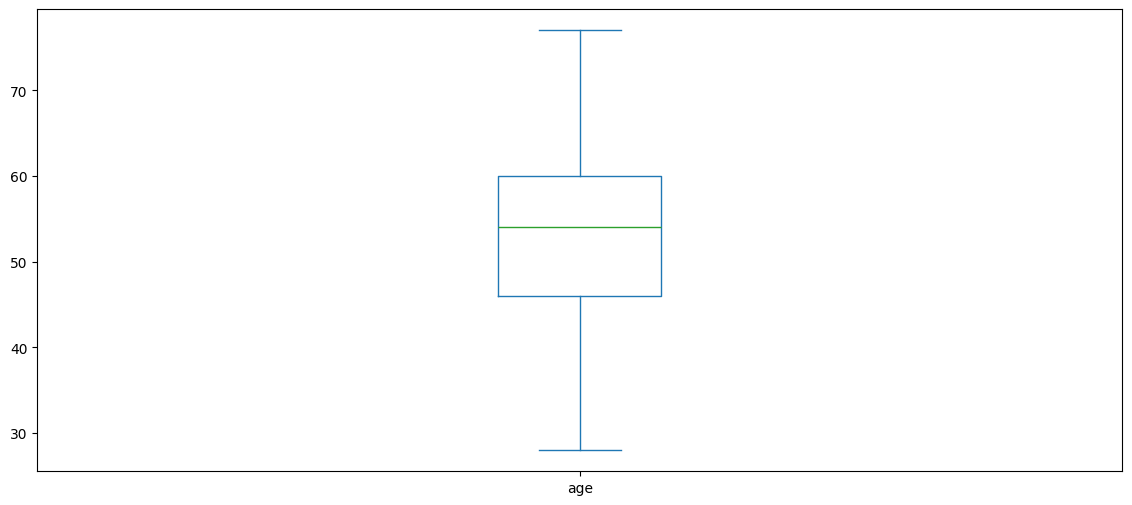

In [52]:
Hrt['age'].plot(kind='box' , vert=True, figsize=(14,6))

<Axes: >

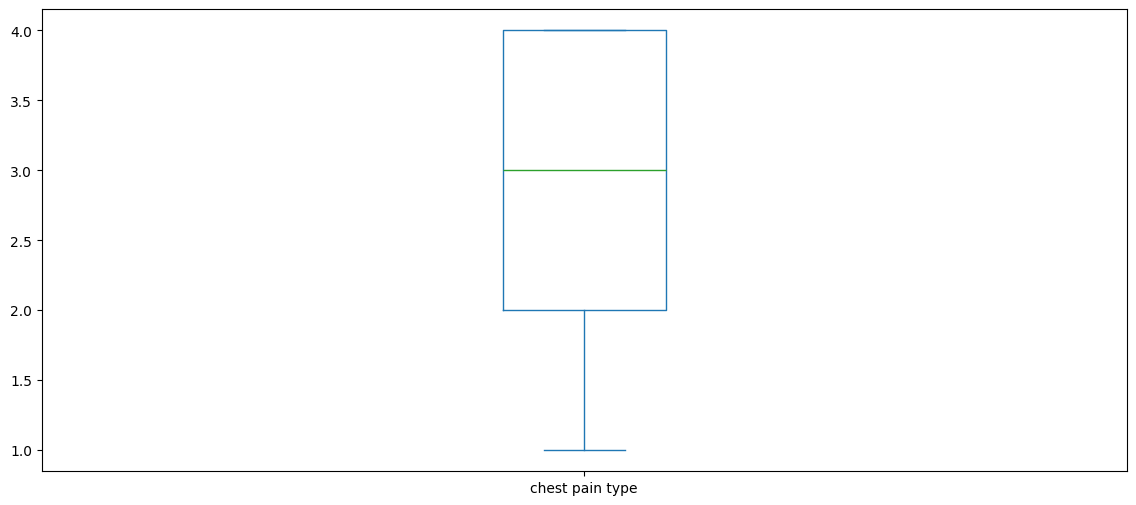

In [53]:
Hrt['chest pain type'].plot(kind='box' , vert=True, figsize=(14,6)) 

<Axes: >

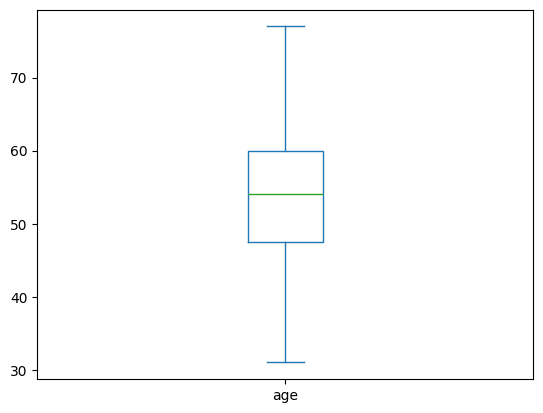

In [54]:
Male['age'].plot(kind='box')

<Axes: >

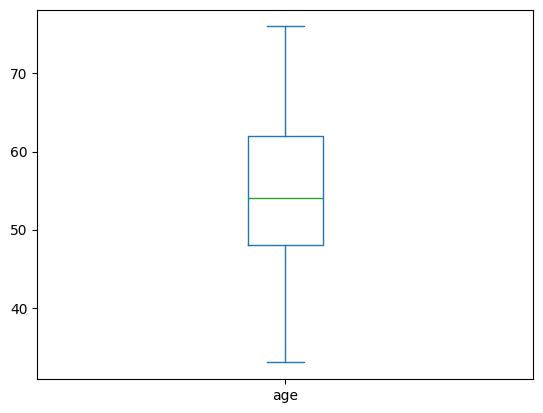

In [55]:
Female['age'].plot(kind = 'box')

In [59]:
ECG_Female.plot(ECG_Female['resting ecg'],ECG_Female['age'])
ECG_Female.title()
ECG_Female.xlabel('X')
ECG_Female.ylabel('Y')
ECG_Female.legend('X','Y')
plt.show

KeyError: "None of [Index([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,\n       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,\n       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,\n       1, 1, 1],\n      dtype='int64')] are in the [columns]"

In [ ]:
ECG_Male

In [ ]:
Angina_No_Col_High

In [ ]:
Angina_Yes_Col_High

In [ ]:
High_Col_Pain

In [ ]:
Low_Col_Pain

In [ ]:
Resting_High_HR

In [ ]:
High_Peak_ECG